In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
adata = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/STR_zonation_references_h5ad/STR_D1D2_Hybrid_MSN_4_zones.h5ad")
print(adata)
adata = adata[adata.obs["x"].notna() & adata.obs["y"].notna()].copy()
adata.obsm["spatial"] = np.array([adata.obs["x"], adata.obs["y"]]).T
adata.obs[["x", "y"]].dropna().to_csv("/home/gdallagl/myworkdir/XDP/data/_old/d1d2.csv", index=True)


AnnData object with n_obs × n_vars = 578 × 37905
    obs: 'orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'PREFIX', 'CELL_BARCODE', 'NUM_GENIC_READS', 'NUM_TRANSCRIPTS', 'NUM_GENES', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_genic', 'pct_intronic', 'pct_mt', 'pct_ribosomal', 'frac_contamination', 'experiment', 'donor_external_id', 'is_primary_data', 'Neighborhood_label', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Class_label', 'Class_name', 'Class_bootstrapping_probability', 'Subclass_label', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Group_label', 'Group_name', 'Group_bootstrapping_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'donor_id', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'x', 'y', 'RNA_snn_res.0.8', 'seurat_clusters', 'library', 'donor', 'x_um2', 'y_um2', 'unique_cell_ID', 'AK_celltype', 'RNA_snn_res.0.2', 'cb', 'clusters', 'num_dbscan', 'logu

In [3]:
sc.pp.filter_genes(adata, min_cells=1) 
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers["log1p_norm"] = adata.X.copy()
adata

AnnData object with n_obs × n_vars = 512 × 31198
    obs: 'orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'PREFIX', 'CELL_BARCODE', 'NUM_GENIC_READS', 'NUM_TRANSCRIPTS', 'NUM_GENES', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_genic', 'pct_intronic', 'pct_mt', 'pct_ribosomal', 'frac_contamination', 'experiment', 'donor_external_id', 'is_primary_data', 'Neighborhood_label', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Class_label', 'Class_name', 'Class_bootstrapping_probability', 'Subclass_label', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Group_label', 'Group_name', 'Group_bootstrapping_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'donor_id', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'x', 'y', 'RNA_snn_res.0.8', 'seurat_clusters', 'library', 'donor', 'x_um2', 'y_um2', 'unique_cell_ID', 'AK_celltype', 'RNA_snn_res.0.2', 'cb', 'clusters', 'num_dbscan', 'logu

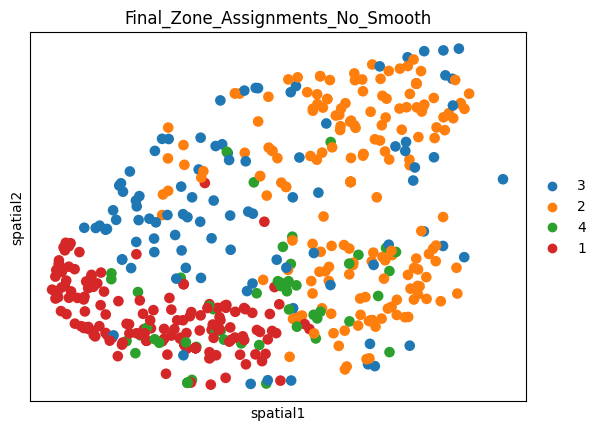

In [4]:
sc.pl.embedding(adata, basis="spatial", color="Final_Zone_Assignments_No_Smooth")


# Load spline data

In [5]:
df_spline= pd.read_csv("/home/gdallagl/myworkdir/XDP/data/_old/my_data.csv", index_col=0)
df_spline["r"] = df_spline["r"] / df_spline["r"].max()  # Normalize to [0, 1]
df_spline

,x,y,d,r
s5_s5_CTATCAGAGCTTCGTT_1,13131.071646,8921.512396,-4349.618568,0.290239
s5_s5_AGCTTCCGTCTGTGGA_1,17705.865490,22870.886435,3192.543395,0.749590
s5_s5_CCGATTAAGACAATTC_1,11729.829212,3963.885580,-7783.570974,0.147979
s5_s5_CTTCGTTAGCGTTGTA_1,4098.607582,11168.837789,2476.229178,0.070635
s5_s5_CCTTGCCAGCGTGGTT_1,8646.146158,6694.461111,-3790.590776,0.111829
...,...,...,...,...
s5_s5_CTCTCCGCAGTATACC_8,18228.211250,28097.063571,3887.020305,1.000000
s5_s5_GCTCCGTTCAGGGACA_8,15781.751784,8281.436931,-6338.381357,0.343769
s5_s5_ATGGGGTCAGTGCTCA_8,8610.918785,6610.215409,-3840.069173,0.109078
s5_s5_ACTTCGTTCCTAAGCA_8,17850.503414,8902.254033,-7034.340712,0.407667


In [6]:
adata.obs = adata.obs.merge(df_spline, left_index=True, right_index=True, how="left")
adata.obs

,orig.ident,nCount_originalexp,nFeature_originalexp,PREFIX,CELL_BARCODE,NUM_GENIC_READS,NUM_TRANSCRIPTS,NUM_GENES,num_retained_transcripts,pct_coding,...,Clusters_3,Clusters_5,Clusters_6,Clusters_9,Clusters_8,Clusters_7,x_y,y_y,d,r
s5_s5_CTATCAGAGCTTCGTT_1,2024-10-25,35960,6850,2024-10-25_s5_Slide-tag_10X-GEMX-5P-GEX_BN_rxn1,CTATCAGAGCTTCGTT,62007,35493,6699,35092,0.1999,...,1,1,1,5,4,1,13131.071646,8921.512396,-4349.618568,0.290239
s5_s5_AGCTTCCGTCTGTGGA_1,2024-10-25,155216,11174,2024-10-25_s5_Slide-tag_10X-GEMX-5P-GEX_BN_rxn1,AGCTTCCGTCTGTGGA,285023,150548,10768,150277,0.1873,...,1,1,1,2,3,1,17705.865490,22870.886435,3192.543395,0.749590
s5_s5_CCGATTAAGACAATTC_1,2024-10-25,53172,7501,2024-10-25_s5_Slide-tag_10X-GEMX-5P-GEX_BN_rxn1,CCGATTAAGACAATTC,97674,51977,7278,51668,0.1654,...,3,2,2,3,1,2,11729.829212,3963.885580,-7783.570974,0.147979
s5_s5_CTTCGTTAGCGTTGTA_1,2024-10-25,83854,10111,2024-10-25_s5_Slide-tag_10X-GEMX-5P-GEX_BN_rxn1,CTTCGTTAGCGTTGTA,148105,81768,9774,81508,0.2120,...,2,3,4,1,2,3,4098.607582,11168.837789,2476.229178,0.070635
s5_s5_CCTTGCCAGCGTGGTT_1,2024-10-25,117378,10147,2024-10-25_s5_Slide-tag_10X-GEMX-5P-GEX_BN_rxn1,CCTTGCCAGCGTGGTT,211667,114099,9725,113838,0.1394,...,3,2,2,3,1,2,8646.146158,6694.461111,-3790.590776,0.111829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
s5_s5_CTCTCCGCAGTATACC_8,2024-10-25,105148,9411,2024-10-25_s5_Slide-tag_10X-GEMX-5P-GEX_BN_rxn8,CTCTCCGCAGTATACC,208576,101830,8992,101469,0.1532,...,1,1,1,4,5,4,18228.211250,28097.063571,3887.020305,1.000000
s5_s5_GCTCCGTTCAGGGACA_8,2024-10-25,103573,10209,2024-10-25_s5_Slide-tag_10X-GEMX-5P-GEX_BN_rxn8,GCTCCGTTCAGGGACA,216349,100935,9857,100482,0.2146,...,1,1,1,7,4,1,15781.751784,8281.436931,-6338.381357,0.343769
s5_s5_ATGGGGTCAGTGCTCA_8,2024-10-25,12499,4236,2024-10-25_s5_Slide-tag_10X-GEMX-5P-GEX_BN_rxn8,ATGGGGTCAGTGCTCA,29406,13309,4416,12204,0.1795,...,2,5,5,8,7,6,8610.918785,6610.215409,-3840.069173,0.109078
s5_s5_ACTTCGTTCCTAAGCA_8,2024-10-25,184876,11119,2024-10-25_s5_Slide-tag_10X-GEMX-5P-GEX_BN_rxn8,ACTTCGTTCCTAAGCA,361762,178449,10541,178122,0.1169,...,1,1,1,2,3,1,17850.503414,8902.254033,-7034.340712,0.407667


In [7]:
# Separately for caudate and putamen
adata.obs["region"] = np.where(adata.obs["d"] < 0, "caudate", "putamen")  # crude split just for testing

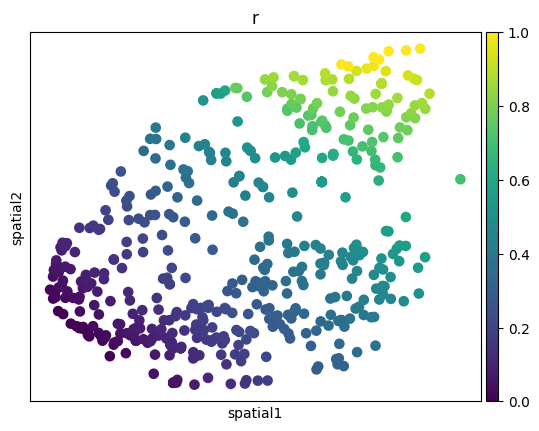

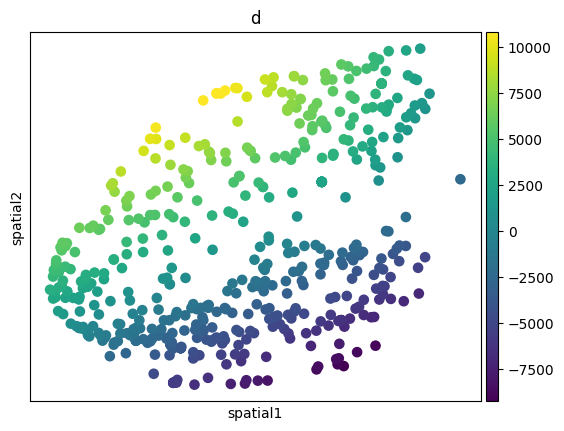

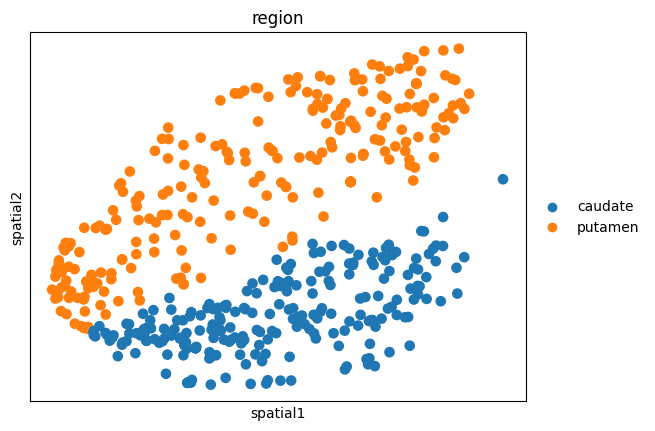

In [8]:
sc.pl.embedding(adata, basis="spatial", color="r")
sc.pl.embedding(adata, basis="spatial", color="d")
sc.pl.embedding(adata, basis="spatial", color="region")

# Add r by PCA

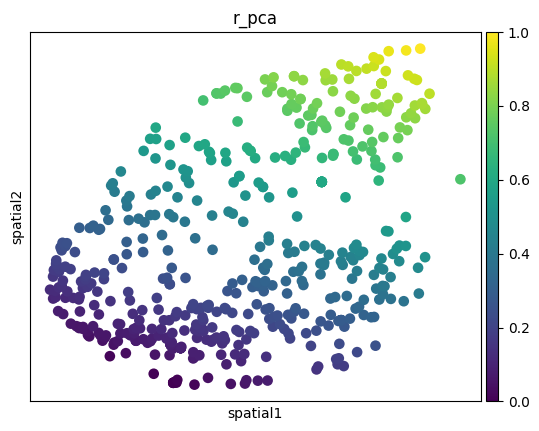

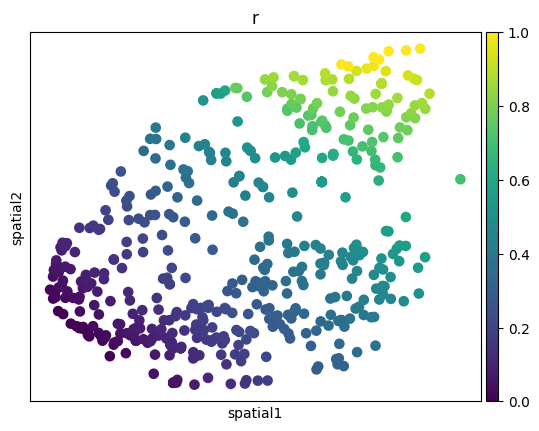

In [9]:
from sklearn.decomposition import PCA

def compute_dv_score(coords):
    """Project cells onto their first principal spatial axis, normalize to [0,1]"""
    pca = PCA(n_components=1)
    r = pca.fit_transform(coords).ravel()
    return (r - r.min()) / (r.max() - r.min())

adata.obs["r_pca"] = compute_dv_score(adata.obsm["spatial"])

sc.pl.embedding(adata, basis="spatial", color="r_pca")
sc.pl.embedding(adata, basis="spatial", color="r")


# Calcualte correltion

In [ ]:
import numpy as np
import pandas as pd
from scipy import sparse
from scipy.stats import rankdata
from scipy.stats import t as tdist
from scipy.stats import spearmanr

def calc_spatial_corr_for_each_gene(adata, metric_key="r"):
    adata = adata.copy()
    sc.pp.filter_genes(adata, min_cells=1) 
    # cells x genes
    X = adata.layers["log1p_norm"].copy()
    X = X.toarray() if sparse.issparse(X) else np.asarray(X)
    X = X.astype(float)

    metric = adata.obs[metric_key].values.astype(float)
    n = X.shape[0]

    # rank once; 'average' ranks handle the many tied zeros correctly (same as scipy)
    Xr = rankdata(X, axis=0)        # needs scipy >= 1.10 for axis=
    yr = rankdata(metric)

    # center
    Xr -= Xr.mean(axis=0)
    yr -= yr.mean()

    # Pearson on ranks == Spearman, all genes at once
    rho = (Xr.T @ yr) / np.sqrt((Xr**2).sum(axis=0) * (yr**2).sum())

    # vectorized two-sided p-value (t-approx, matches spearmanr's default for non-tiny n)
    with np.errstate(divide="ignore", invalid="ignore"):
        tstat = rho * np.sqrt((n - 2) / (1 - rho**2))
    pval = 2 * tdist.sf(np.abs(tstat), df=n - 2)

    res = pd.DataFrame({"gene": adata.var_names, "rho": rho, "pval": pval})
    res = res.sort_values("rho", key=np.abs, ascending=False)

    from statsmodels.stats.multitest import multipletests
    res["padj"] = multipletests(res["pval"], method="fdr_bh")[1]

    sns.histplot(res["rho"], bins=50)

    res.set_index("gene", inplace=True)

    display(res.sort_values("rho", key=np.abs, ascending=False))

    return res


# df_corr_r: rather than recomputing gene~r correlation from this notebook's single small
# reference dataset, load the multi-donor (18 healthy donors) meta-analyzed correlation for
# the same "r" spline metric from find_spatial_grad_gene_MSN_types_refactored.ipynb — more
# samples, more power. Uses the whole-healthy table (df_corr_r_d1d2.csv), not the range-matched
# one (df_corr_r_d1d2_matched.csv). Genes that don't clear that notebook's significance/expression
# gates are dropped (rho -> NaN), so they carry no weight in compute_raw_score below.
CORR_DIR = "/home/gdallagl/myworkdir/XDP/data/BICAN/bican_spatial_zonated/genes_correlation"
PADJ_THR, MIN_PCT_EXPR, MIN_MEAN_EXPR = 0.05, 0.20, 0.10

df_corr_r = pd.read_csv(f"{CORR_DIR}/df_corr_r_d1d2.csv", index_col=0)
passes = (
    (df_corr_r["padj"] < PADJ_THR) &
    (df_corr_r["pct_expr"] >= MIN_PCT_EXPR) &
    (df_corr_r["mean_expr"] >= MIN_MEAN_EXPR)
)
print(f"{passes.sum()} / {len(df_corr_r)} genes pass padj<{PADJ_THR}, pct_expr>={MIN_PCT_EXPR}, mean_expr>={MIN_MEAN_EXPR}")
df_corr_r.loc[~passes, "rho"] = np.nan

sns.histplot(df_corr_r["rho"], bins=50); plt.show()
display(df_corr_r.sort_values("rho", key=np.abs, ascending=False))

# No multi-donor equivalent exists for r_pca or the caudate/putamen split, so these are still
# computed from scratch on this notebook's own (small) reference dataset.
df_corr_r_pca = calc_spatial_corr_for_each_gene(adata, metric_key="r_pca")
df_corr_r_caudate = calc_spatial_corr_for_each_gene(adata[adata.obs["region"] == "caudate"].copy(), metric_key="r")
df_corr_r_pca_caudate = calc_spatial_corr_for_each_gene(adata[adata.obs["region"] == "caudate"].copy(), metric_key="r_pca")
df_corr_r_putamen = calc_spatial_corr_for_each_gene(adata[adata.obs["region"] == "putamen"].copy(), metric_key="r")
df_corr_r_pca_putamen = calc_spatial_corr_for_each_gene(adata[adata.obs["region"] == "putamen"].copy(), metric_key="r_pca")

In [11]:
all_rho = (
    df_corr_r[["rho"]].rename(columns={"rho": "r"})
    .join(df_corr_r_pca[["rho"]].rename(columns={"rho": "r_pca"}), how="outer")
    .join(df_corr_r_caudate[["rho"]].rename(columns={"rho": "r_caudate"}), how="outer")
    .join(df_corr_r_pca_caudate[["rho"]].rename(columns={"rho": "r_pca_caudate"}), how="outer")
    .join(df_corr_r_putamen[["rho"]].rename(columns={"rho": "r_putamen"}), how="outer")
    .join(df_corr_r_pca_putamen[["rho"]].rename(columns={"rho": "r_pca_putamen"}), how="outer")
)

print(all_rho.shape)  # full union of genes
print(all_rho.isna().sum())  # how many genes are missing per condition
all_rho


(31198, 6)
r                   0
r_pca               0
r_caudate        1761
r_pca_caudate    1761
r_putamen        1669
r_pca_putamen    1669
dtype: int64


,r,r_pca,r_caudate,r_pca_caudate,r_putamen,r_pca_putamen
gene,,,,,,
A1BG,0.030291,0.051146,0.060739,0.048055,-0.037361,-0.035448
A1BG-AS1,-0.003131,0.010966,-0.006461,0.002305,-0.046581,-0.046137
A1CF,-0.027823,-0.036673,-0.042603,-0.118528,-0.039266,-0.042962
A2M,-0.051886,-0.017772,-0.024158,0.002924,-0.097339,-0.093554
A2M-AS1,0.035383,0.014616,-0.010756,-0.008312,0.116643,0.120689
...,...,...,...,...,...,...
ZYG11A,-0.035994,-0.018326,-0.003845,0.007885,-0.073619,-0.072872
ZYG11B,0.004451,0.007569,0.079666,0.095712,-0.033632,-0.025082
ZYX,0.043045,0.022811,-0.023252,-0.012682,0.123074,0.120715


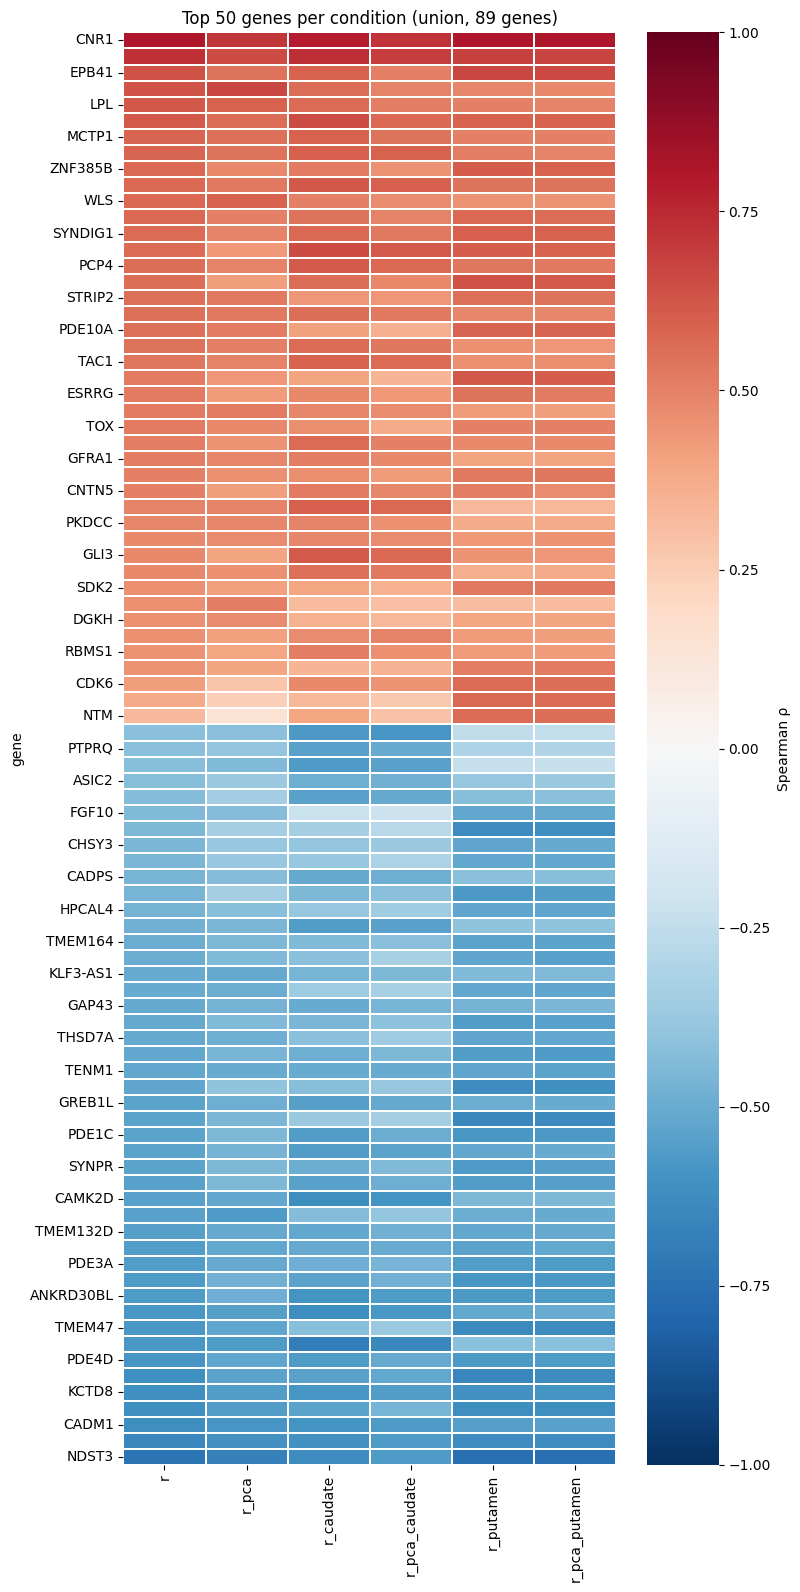

In [12]:
N = 50  # top genes by |rho| in each condition
top_genes = set()
for df in [df_corr_r, df_corr_r_pca, df_corr_r_caudate,
           df_corr_r_pca_caudate, df_corr_r_putamen, df_corr_r_pca_putamen]:
    top_genes.update(df["rho"].abs().nlargest(N).index)

heatmap_df = all_rho.loc[all_rho.index.isin(top_genes)].sort_values("r", ascending=False)

fig, ax = plt.subplots(figsize=(8, max(6, len(heatmap_df) * 0.18)))
sns.heatmap(heatmap_df, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.2, ax=ax, cbar_kws={"label": "Spearman ρ"})
ax.set_title(f"Top {N} genes per condition (union, {len(heatmap_df)} genes)")
plt.tight_layout()
plt.show()


<Axes: xlabel='r_pca_caudate', ylabel='r_pca_putamen'>

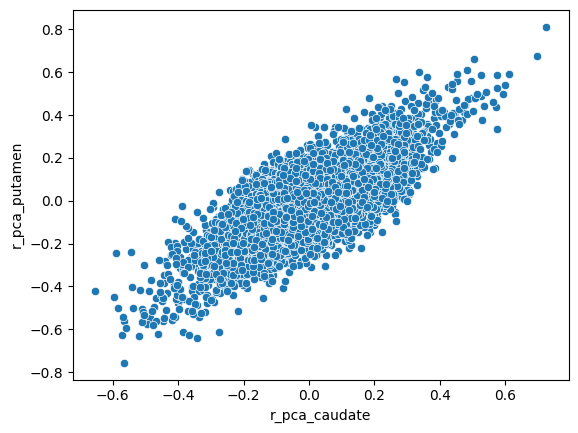

In [13]:
# Are there geens speifific for caudate or putamane?

pc_df = all_rho[["r_pca_caudate", "r_pca_putamen"]].copy()
sns.scatterplot(data=pc_df, x="r_pca_caudate", y="r_pca_putamen")

# Are same genes of matrix gradient

In [14]:
df_grad_matrix = pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/dorsal_ventral_gradient/exp_by_spline_combined.csv").dropna()
df_grad_matrix["mean_spearman"] = -df_grad_matrix["mean_spearman"] 
df_grad_matrix


,gene,mean_spearman,combined_p
0,A1BG,0.002360,5.349057e-07
1,A1BG-AS1,0.007881,3.198023e-08
2,A1CF,-0.007398,2.969691e-02
3,A2M,0.002144,8.049117e-15
4,A2M-AS1,0.000389,7.443913e-03
...,...,...,...
51536,ENSG00000275869,-0.010320,1.923158e-01
51537,ENSG00000273554,-0.006670,3.994321e-01
51540,ENSG00000276017,0.008289,2.949804e-01
51541,ENSG00000278817,0.027789,4.458387e-04


In [15]:
df_grad_matrix = df_grad_matrix.merge(all_rho, left_on="gene", right_index=True, how="left")
df_grad_matrix

,gene,mean_spearman,combined_p,r,r_pca,r_caudate,r_pca_caudate,r_putamen,r_pca_putamen
0,A1BG,0.002360,5.349057e-07,0.030291,0.051146,0.060739,0.048055,-0.037361,-0.035448
1,A1BG-AS1,0.007881,3.198023e-08,-0.003131,0.010966,-0.006461,0.002305,-0.046581,-0.046137
2,A1CF,-0.007398,2.969691e-02,-0.027823,-0.036673,-0.042603,-0.118528,-0.039266,-0.042962
3,A2M,0.002144,8.049117e-15,-0.051886,-0.017772,-0.024158,0.002924,-0.097339,-0.093554
4,A2M-AS1,0.000389,7.443913e-03,0.035383,0.014616,-0.010756,-0.008312,0.116643,0.120689
...,...,...,...,...,...,...,...,...,...
51536,ENSG00000275869,-0.010320,1.923158e-01,NaN,NaN,NaN,NaN,NaN,NaN
51537,ENSG00000273554,-0.006670,3.994321e-01,NaN,NaN,NaN,NaN,NaN,NaN
51540,ENSG00000276017,0.008289,2.949804e-01,0.073778,0.073778,NaN,NaN,0.100087,0.100087
51541,ENSG00000278817,0.027789,4.458387e-04,0.019370,0.045231,-0.001379,0.013088,0.000947,0.003539


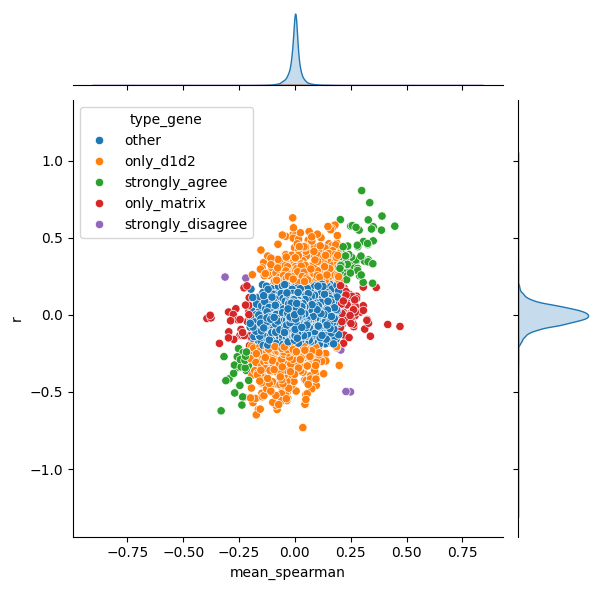

<Axes: xlabel='mean_spearman', ylabel='Count'>

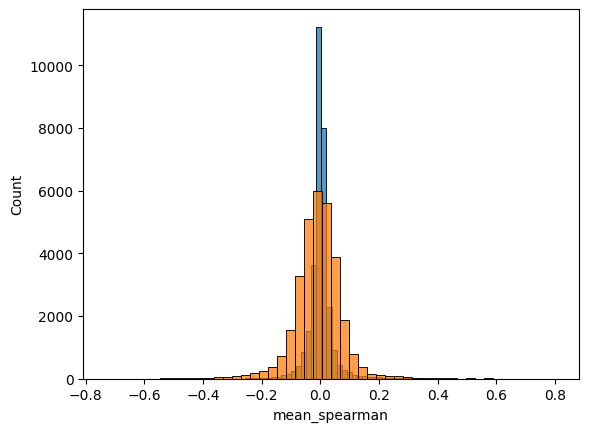

In [16]:
df_grad_matrix = df_grad_matrix[["gene", "mean_spearman", "r"]].dropna()

s = df_grad_matrix["mean_spearman"]
r = df_grad_matrix["r"]

both_strong = (s.abs() > 0.2) & (r.abs() > 0.2)

df_grad_matrix["strongly_agree"]    = both_strong & (np.sign(s) == np.sign(r))
df_grad_matrix["strongly_disagree"] = both_strong & (np.sign(s) != np.sign(r))

df_grad_matrix["only_d1d2"]   = (s.abs() < 0.2) & (r.abs() >= 0.2)
df_grad_matrix["only_matrix"] = (s.abs() >= 0.2) & (r.abs() < 0.2)

# collapse into a single label column
df_grad_matrix["type_gene"] = "other"
df_grad_matrix.loc[df_grad_matrix["strongly_agree"],    "type_gene"] = "strongly_agree"
df_grad_matrix.loc[df_grad_matrix["strongly_disagree"], "type_gene"] = "strongly_disagree"
df_grad_matrix.loc[df_grad_matrix["only_d1d2"],         "type_gene"] = "only_d1d2"
df_grad_matrix.loc[df_grad_matrix["only_matrix"],       "type_gene"] = "only_matrix"

sns.jointplot(data=df_grad_matrix, x="mean_spearman", y="r", hue="type_gene"); plt.show()
sns.histplot(df_grad_matrix, x="mean_spearman", bins=50)
sns.histplot(df_grad_matrix, x="r", bins=50)

In [17]:
display(df_grad_matrix[df_grad_matrix["type_gene"] == "strongly_disagree"])
df_grad_matrix[df_grad_matrix["type_gene"] == "strongly_agree"].sort_values("r") 
display(df_grad_matrix[df_grad_matrix["type_gene"] == "only_d1d2"].sort_values("r") )

display(df_grad_matrix[df_grad_matrix["type_gene"] == "only_matrix"].sort_values("mean_spearman") )
display(df_grad_matrix[df_grad_matrix["gene"].isin(["PLEKHA7"])])


,gene,mean_spearman,r,strongly_agree,strongly_disagree,only_d1d2,only_matrix,type_gene
14520,CDH12,-0.219584,0.238210,False,True,False,False,strongly_disagree
14888,CHRM3,0.249289,-0.499776,False,True,False,False,strongly_disagree
18186,GALNTL6,-0.312589,0.245133,False,True,False,False,strongly_disagree
18824,GRM3,0.228656,-0.497606,False,True,False,False,strongly_disagree
19943,INPP5A,0.205716,-0.228193,False,True,False,False,strongly_disagree


,gene,mean_spearman,r,strongly_agree,strongly_disagree,only_d1d2,only_matrix,type_gene
24844,NDST3,0.035661,-0.731256,False,False,True,False,only_d1d2
14763,CFAP47,-0.172696,-0.648548,False,False,True,False,only_d1d2
13020,BAIAP3,-0.163519,-0.614755,False,False,True,False,only_d1d2
20393,KCTD8,-0.079383,-0.614418,False,False,True,False,only_d1d2
32816,UNC5C,-0.155030,-0.611618,False,False,True,False,only_d1d2
...,...,...,...,...,...,...,...,...
26310,PCP4,0.166196,0.558197,False,False,True,False,only_d1d2
18797,GRIK1,-0.006043,0.564492,False,False,True,False,only_d1d2
33270,WLS,0.148140,0.573001,False,False,True,False,only_d1d2
23727,MCTP1,0.179402,0.581977,False,False,True,False,only_d1d2


,gene,mean_spearman,r,strongly_agree,strongly_disagree,only_d1d2,only_matrix,type_gene
12520,ARHGAP6,-0.393592,-0.023553,False,False,False,True,only_matrix
27342,PRKG1,-0.379187,-0.002792,False,False,False,True,only_matrix
18289,GDA,-0.375323,-0.019776,False,False,False,True,only_matrix
19063,HCN1,-0.337687,-0.185266,False,False,False,True,only_matrix
34304,ZNF83,-0.297130,-0.149392,False,False,False,True,only_matrix
...,...,...,...,...,...,...,...,...
24095,MME,0.329792,-0.053913,False,False,False,True,only_matrix
33040,VLDLR-AS1,0.337858,-0.138635,False,False,False,True,only_matrix
20852,LARGE1,0.364065,0.177328,False,False,False,True,only_matrix
26830,PLEKHA7,0.415725,-0.062638,False,False,False,True,only_matrix


,gene,mean_spearman,r,strongly_agree,strongly_disagree,only_d1d2,only_matrix,type_gene
26830,PLEKHA7,0.415725,-0.062638,False,False,False,True,only_matrix


# Calcualte DV-D1D2 score on ref

In [18]:
adata_ref = adata.copy()

r
Using 31198 / 31198 genes for scoring


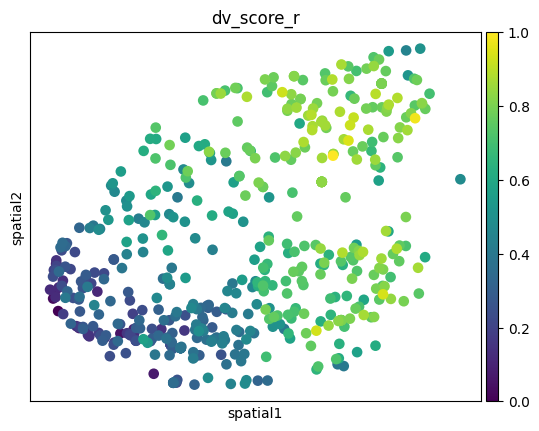

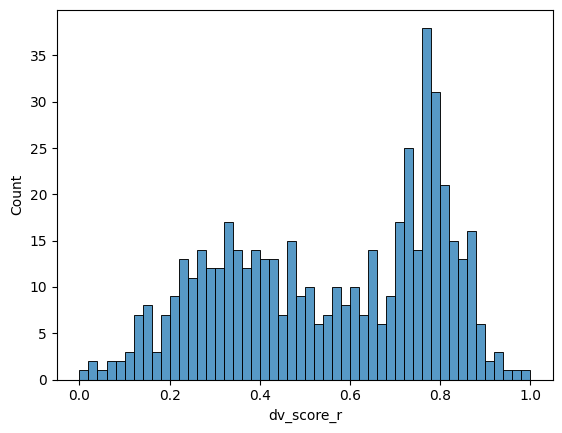

r_pca
Using 31198 / 31198 genes for scoring


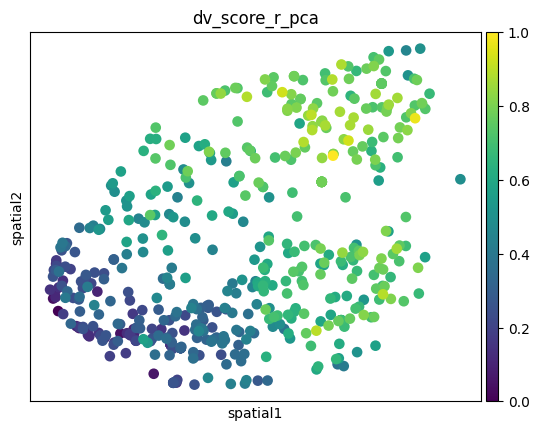

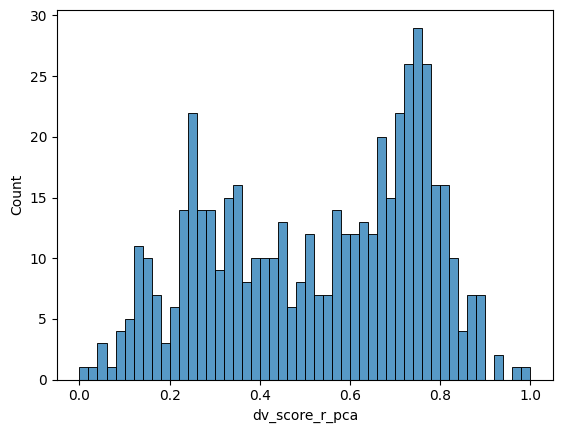

r_caudate
Using 29437 / 29437 genes for scoring


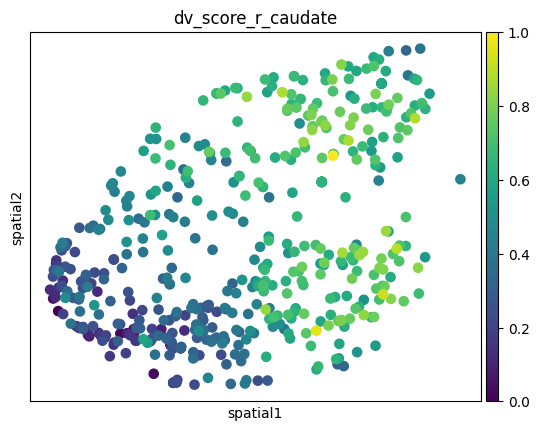

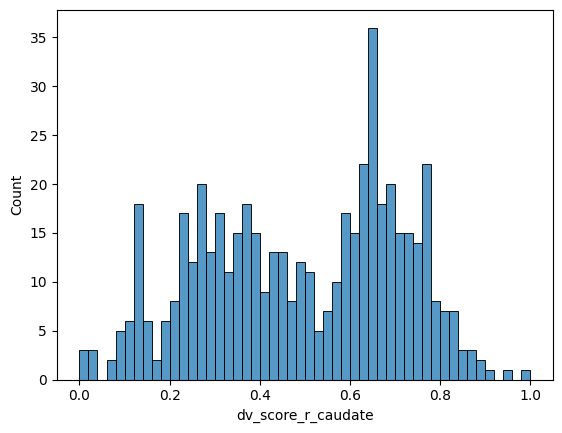

r_pca_caudate
Using 29437 / 29437 genes for scoring


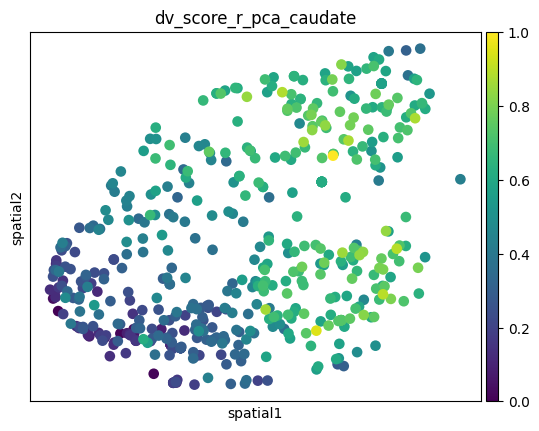

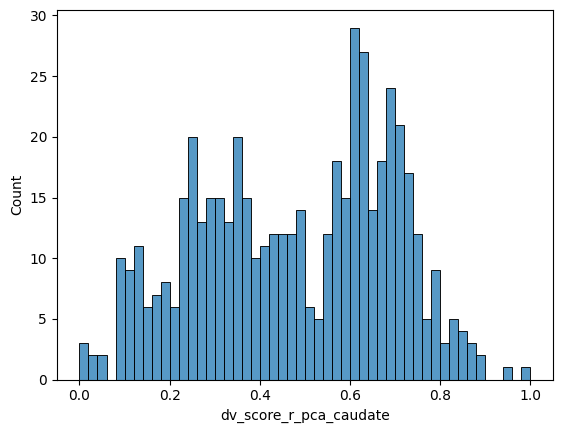

r_putamen
Using 29529 / 29529 genes for scoring


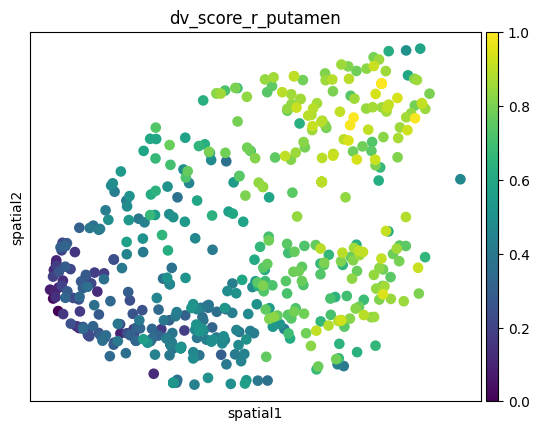

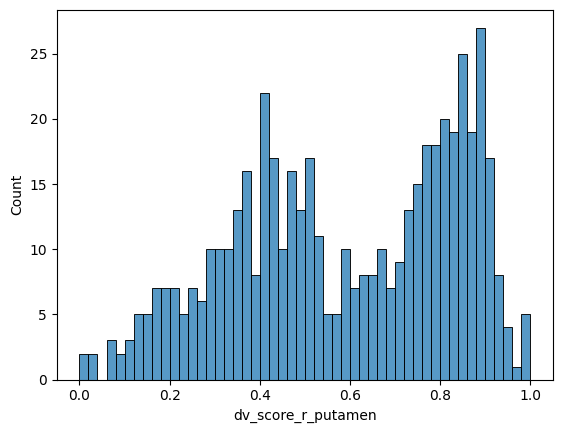

r_pca_putamen
Using 29529 / 29529 genes for scoring


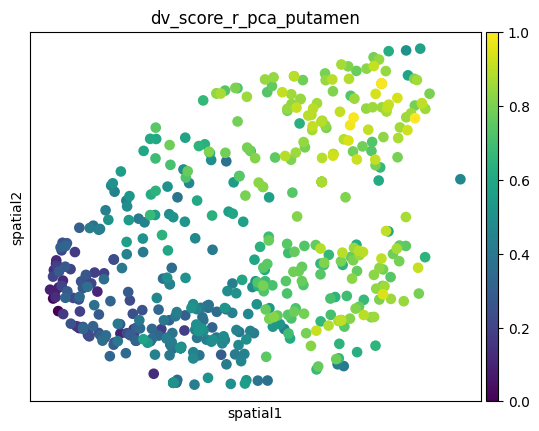

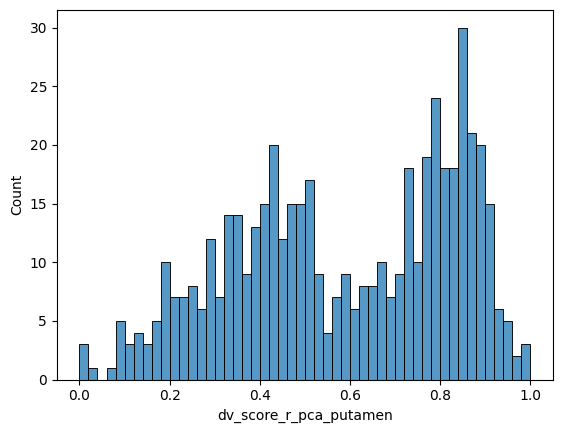

In [19]:
def compute_raw_score(adata, weights, layer=None, score_min=None, score_max=None):
    weights.dropna(inplace=True)  # just in case
    available = [g for g in weights.index if g in adata.var_names]
    print(f"Using {len(available)} / {len(weights)} genes for scoring")
    w = weights[available].values
    X = adata[:, available].layers[layer].toarray() if layer else adata[:, available].X.toarray()
    score = X @ w
    # normalise
    if score_min is None or score_max is None:
        score_min = score.min()
        score_max = score.max()
    else:
        print("This is projection of query dataset")
        print(f"Using provided score_min={score_min:.4f} and score_max={score_max:.4f} for normalization")
    score = (score - score_min) / (score_max - score_min)
    return score, score_min, score_max

weights_r = df_corr_r["rho"]
weights_r_pca = df_corr_r_pca["rho"]
weights_r_caudate = df_corr_r_caudate["rho"]
weights_r_pca_caudate = df_corr_r_pca_caudate["rho"]
weights_r_putamen = df_corr_r_putamen["rho"]
weights_r_pca_putamen = df_corr_r_pca_putamen["rho"]


# Apply same bounds everywhere
scores = ["dv_score_r", "dv_score_r_pca", "dv_score_r_caudate", "dv_score_r_pca_caudate", "dv_score_r_putamen", "dv_score_r_pca_putamen"]
dict_weights = {}

for s in scores:

    name = s.split("dv_score_")[-1]
    print(name)

    weights = all_rho[name]

    adata_ref.obs[s], score_min, score_max = compute_raw_score(adata_ref, weights, layer="log1p_norm")
    sc.pl.embedding(adata_ref, basis="spatial", color=s); plt.show()
    sns.histplot(adata_ref.obs[s], bins=50); plt.show()

    dict_weights[name] = {"name_score": s, f"weights_{name}": weights, f"score_min_{name}": score_min, f"score_max_{name}": score_max}


# Compute score on new dataset

In [26]:
slidetag = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/all_lib_adata_zoned_ct-cured_aligned.h5ad", backed="r")
slidetag.obs["image"] = slidetag.obs["sample"].astype(str) + slidetag.obs["puck"].astype(str)
slidetag.obs["image"] = np.where(slidetag.obs["has_spatial"], slidetag.obs["image"], np.nan)

slidetag.obs["condition"] = slidetag.obs["condition"].map({"healthy": "Control", "diseased": "XDP", "d iseased": "XDP"})


slidetag

AnnData object with n_obs × n_vars = 537658 × 37464 backed at '/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/all_lib_adata_zoned_ct-cured_aligned.h5ad'
    obs: 'x', 'y', 'pct_intronic', 'dbscan_clusters', 'dbscan_score', 'has_spatial', 'sample', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_id', 'donor_number', 'donor_id', 'condition', 'sex', 'age_at_onset', 'age_at_death', 'bcl', 'library', 'Sorted', 'mapping_coupling_for_zoning', 'zone'

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


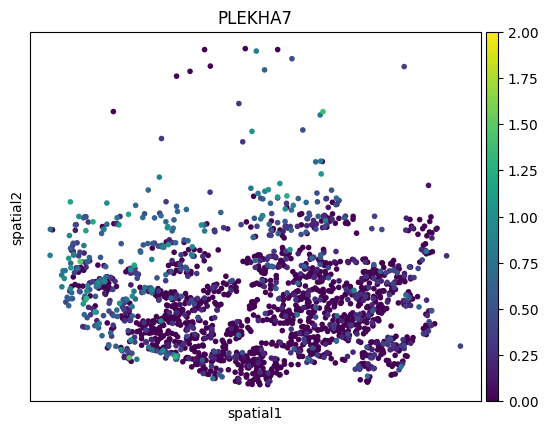

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


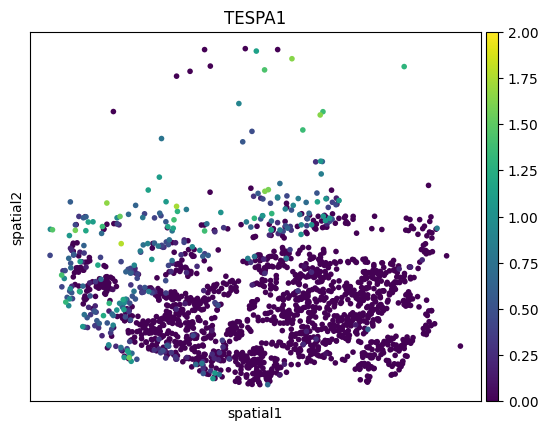

r
Using 31083 / 31198 genes for scoring
This is projection of query dataset
Using provided score_min=-158.8758 and score_max=97.8796 for normalization


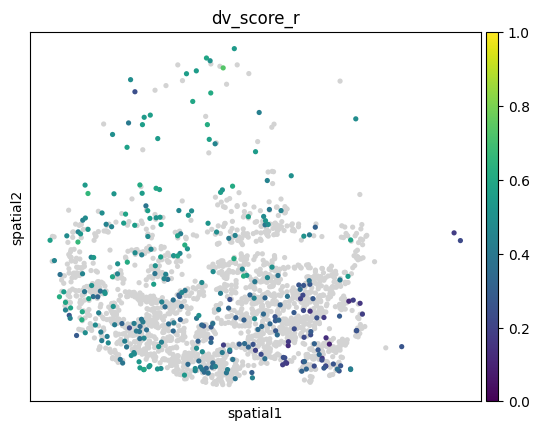

r_pca
Using 31083 / 31198 genes for scoring
This is projection of query dataset
Using provided score_min=-127.6051 and score_max=111.4259 for normalization


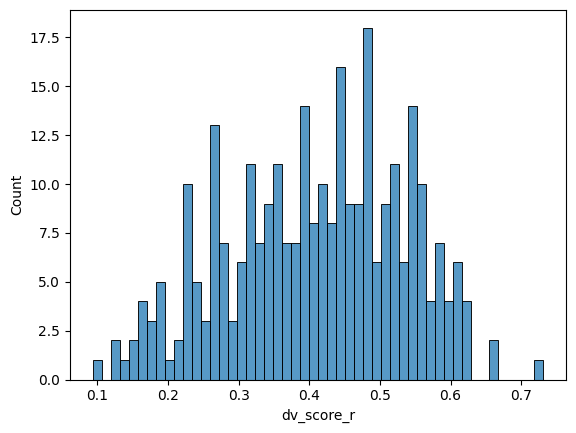

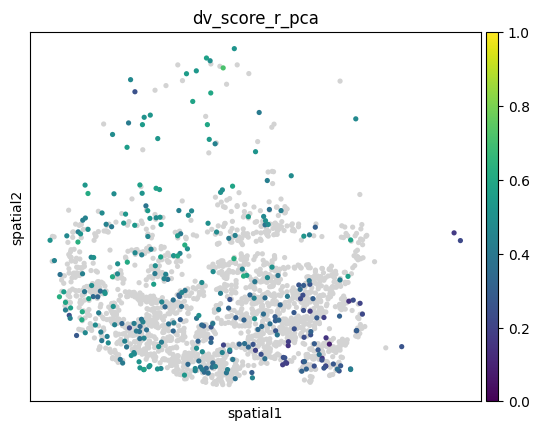

r_caudate
Using 29336 / 29437 genes for scoring
This is projection of query dataset
Using provided score_min=-165.2226 and score_max=117.9946 for normalization


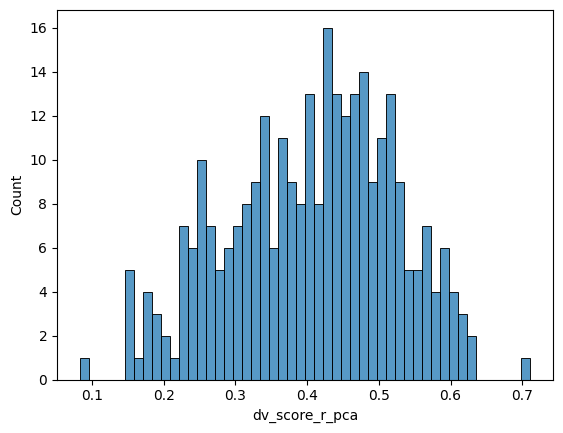

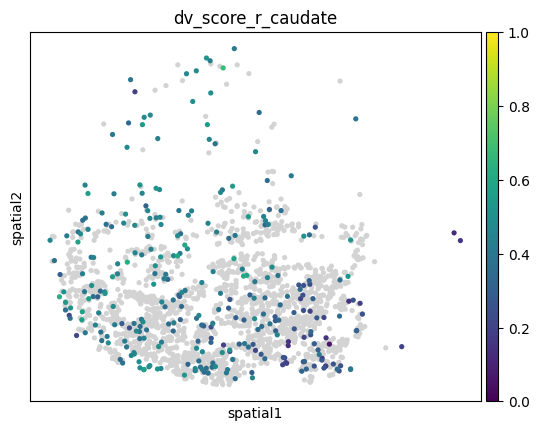

r_pca_caudate
Using 29336 / 29437 genes for scoring
This is projection of query dataset
Using provided score_min=-151.6202 and score_max=122.9525 for normalization


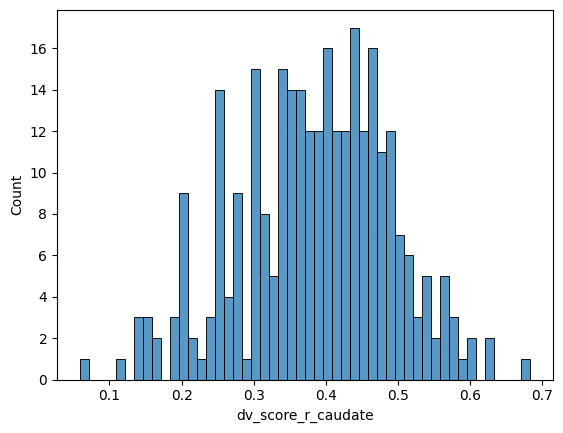

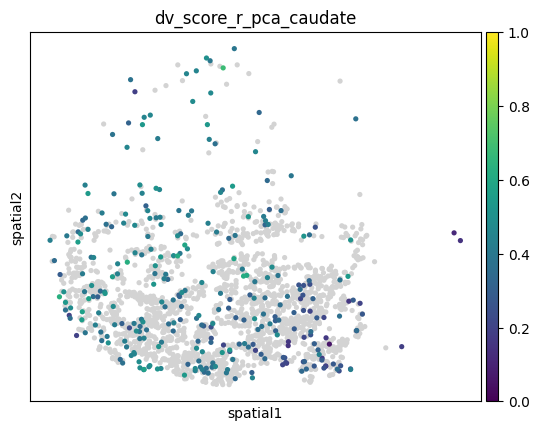

r_putamen
Using 29420 / 29529 genes for scoring
This is projection of query dataset
Using provided score_min=-172.7446 and score_max=68.1637 for normalization


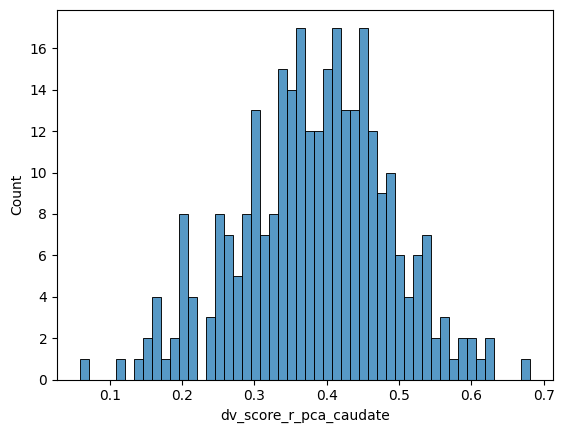

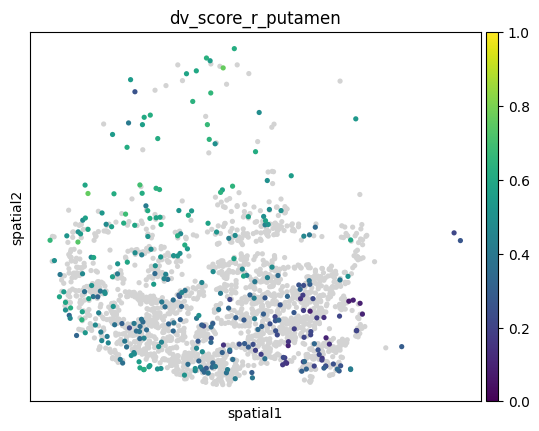

r_pca_putamen
Using 29420 / 29529 genes for scoring
This is projection of query dataset
Using provided score_min=-168.3838 and score_max=71.0229 for normalization


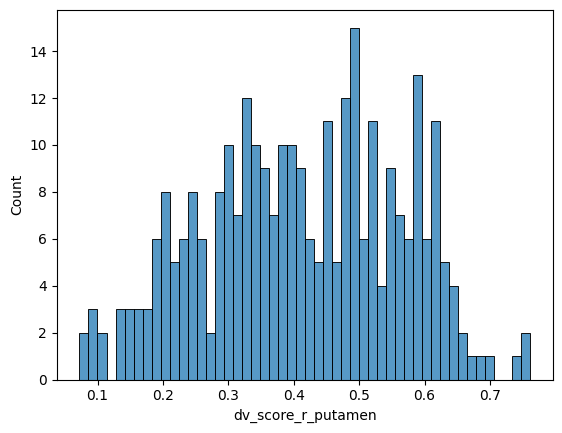

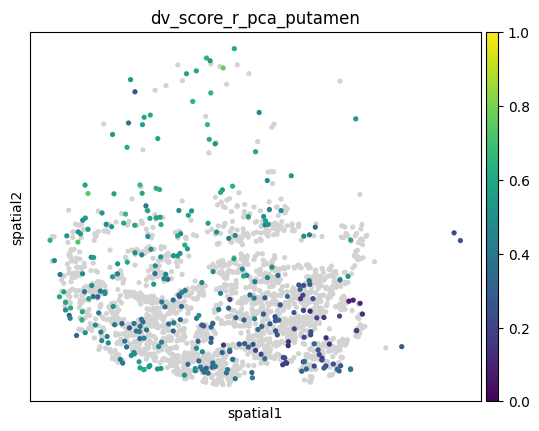

AnnData object with n_obs × n_vars = 2126 × 37464
    obs: 'x', 'y', 'pct_intronic', 'dbscan_clusters', 'dbscan_score', 'has_spatial', 'sample', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_id', 'donor_number', 'donor_id', 'condition', 'sex', 'age_at_onset', 'age_at_death', 'bcl', 'library', 'Sorted', 'mapping_coupling_for_zoning', 'zone', 'zone_probability', 'mapping_coupling_for_zoning_4_zones', 'zone_4', 'zone_4_probability', 'leiden_0.1_all_cel

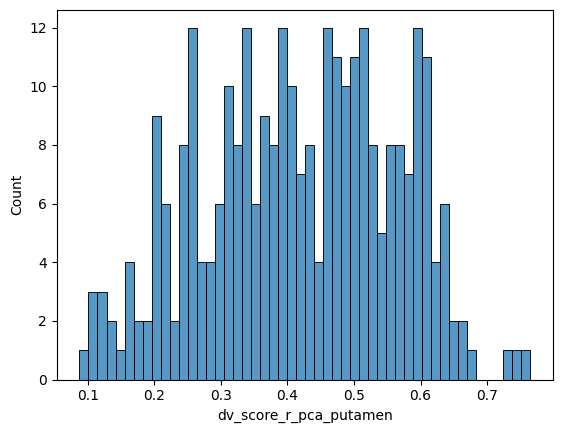

In [27]:
# calculte for a signle sample

slidetag_sample_01 = slidetag[
    (slidetag.obs["image"] == "sample_02puck1") &
    (slidetag.obs["ct_for_deg"].isin(["eMSN_D1D2", "Matrix_D1", "Matrix_D2"])) 
].to_memory().copy()

# # Slidetag (after remapping var_names to gene symbols)
slidetag_sample_01.var_names = slidetag_sample_01.var["gene_symbol"].values.astype(str)
slidetag_sample_01.var_names_make_unique()

for g in df_grad_matrix[df_grad_matrix["type_gene"] == "only_matrix"].sort_values("mean_spearman").tail(2)["gene"]:
    sc.pl.embedding(slidetag_sample_01[slidetag_sample_01.obs["ct_for_deg"].isin(["Matrix_D1", "Matrix_D2"])], basis="spatial", color=g, layer="log1p_norm", vmax=2);plt.show()

for score in dict_weights.keys():
    print(score)

    dict_score = dict_weights[score]

    slidetag_sample_01.obs[dict_score["name_score"]], _, _ = compute_raw_score(slidetag_sample_01, dict_score[f"weights_{score}"], layer="log1p_norm", score_min=dict_score[f"score_min_{score}"], score_max=dict_score[f"score_max_{score}"])

    # just report values for d1d2
    slidetag_sample_01.obs[dict_score["name_score"]] = np.where(
        slidetag_sample_01.obs["ct_for_deg"].isin(["eMSN_D1D2"]),
        slidetag_sample_01.obs[dict_score["name_score"]],
        np.nan,
    )

    sc.pl.embedding(slidetag_sample_01, basis="spatial", color=dict_score["name_score"], vmin=0, vmax=1, )
    sns.histplot(slidetag_sample_01.obs[dict_score["name_score"]], bins=50)

    #break

slidetag_sample_01

# Clautle Phycsal score for matrix based on d1d1 score neirghbors

sample_01puck1


Using 31083 / 31198 genes for scoring
This is projection of query dataset
Using provided score_min=-127.6051 and score_max=111.4259 for normalization


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


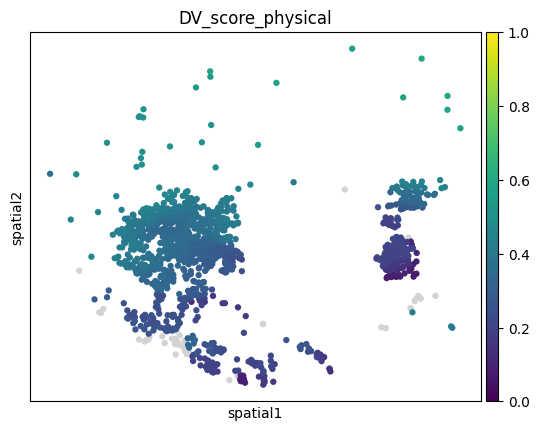

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


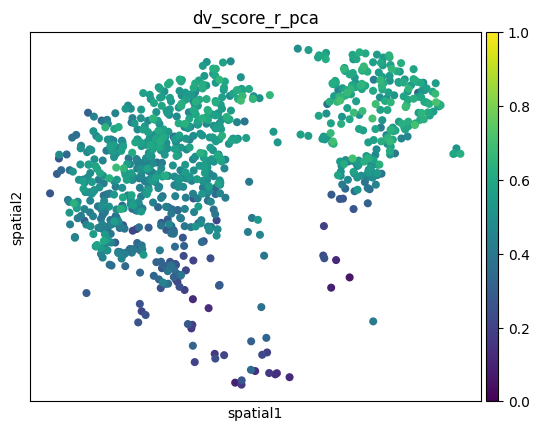

sample_01puck2
Using 31083 / 31198 genes for scoring
This is projection of query dataset
Using provided score_min=-127.6051 and score_max=111.4259 for normalization


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


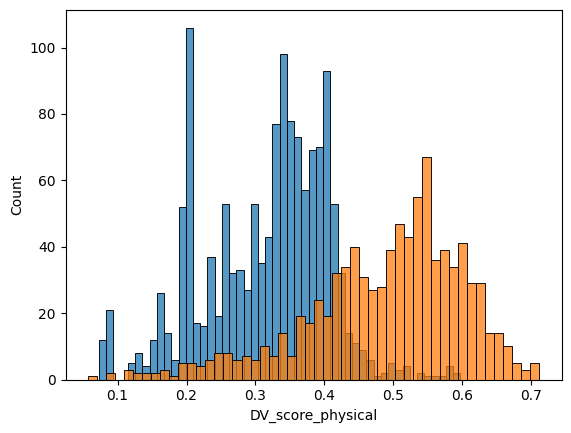

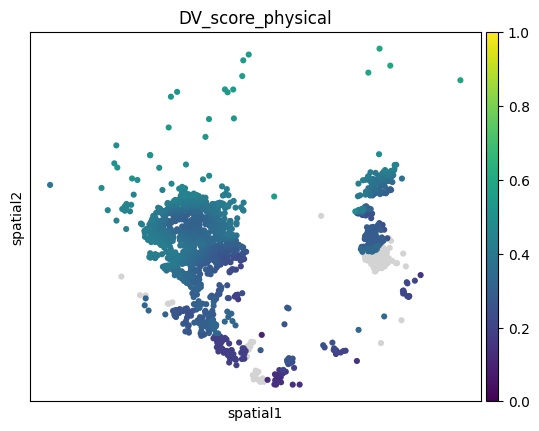

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


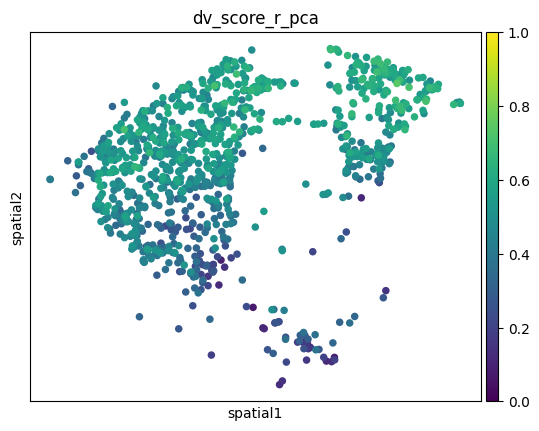

sample_02puck1
Using 31083 / 31198 genes for scoring
This is projection of query dataset
Using provided score_min=-127.6051 and score_max=111.4259 for normalization


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


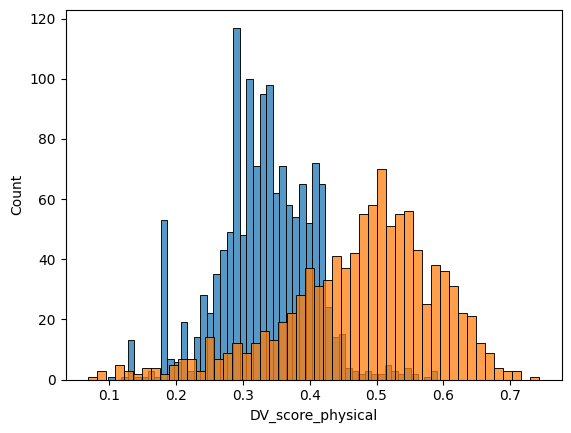

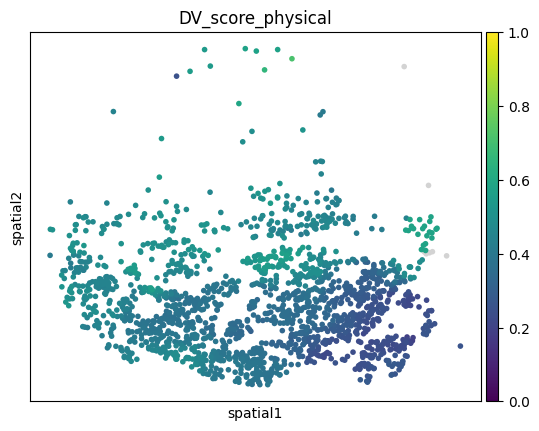

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


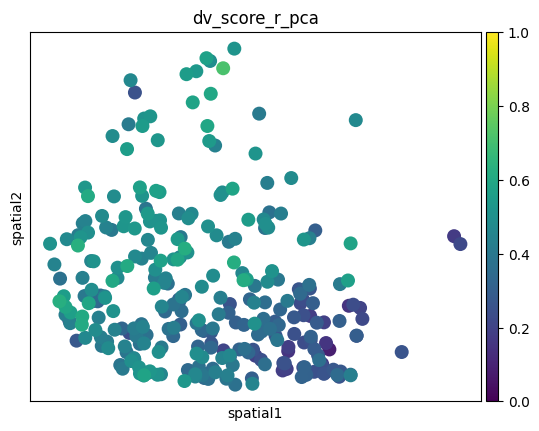

sample_02puck2
Using 31083 / 31198 genes for scoring
This is projection of query dataset
Using provided score_min=-127.6051 and score_max=111.4259 for normalization


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


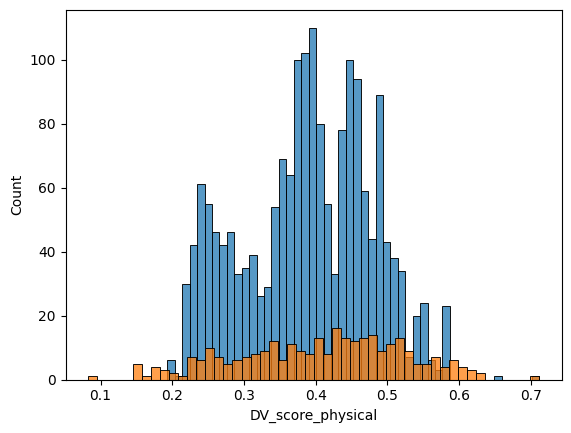

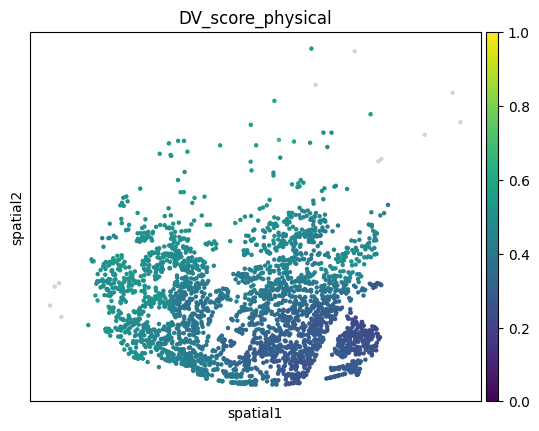

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


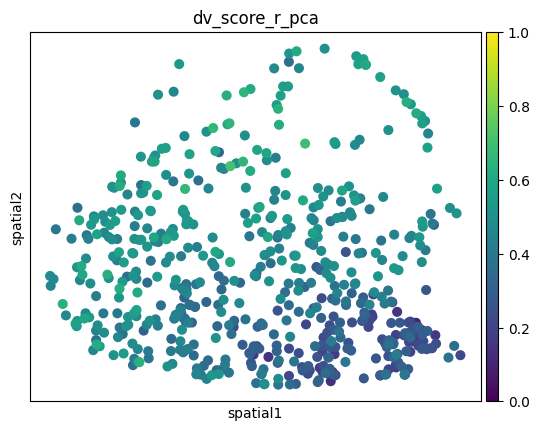

sample_03puck1
Using 31083 / 31198 genes for scoring
This is projection of query dataset
Using provided score_min=-127.6051 and score_max=111.4259 for normalization


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


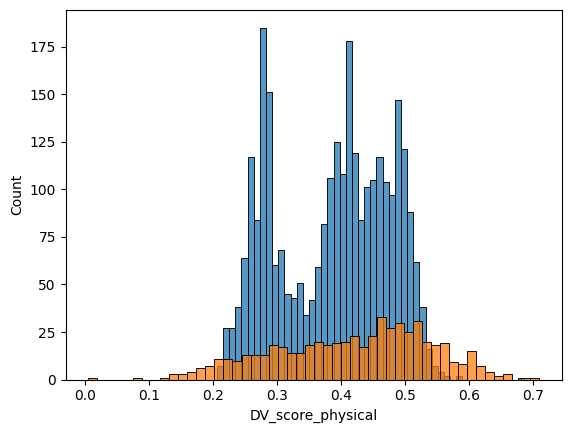

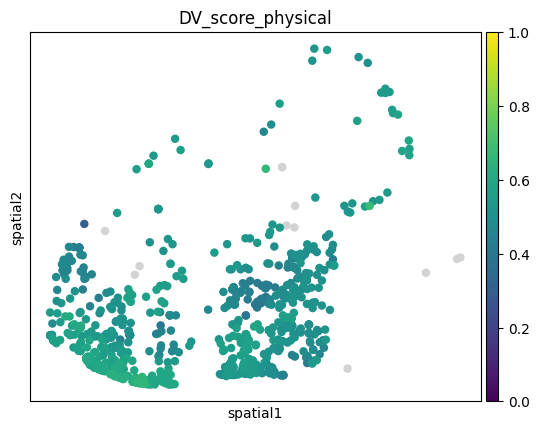

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


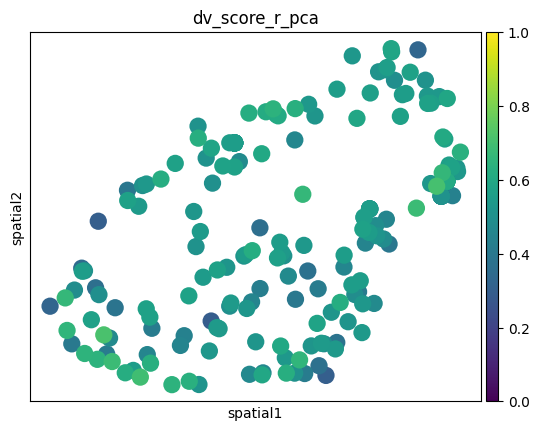

sample_03puck2
Using 31083 / 31198 genes for scoring
This is projection of query dataset
Using provided score_min=-127.6051 and score_max=111.4259 for normalization


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


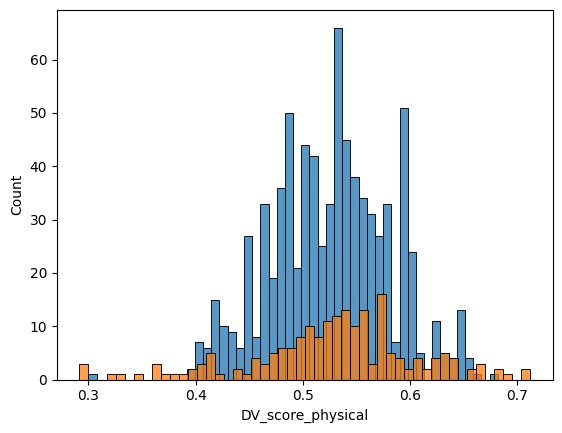

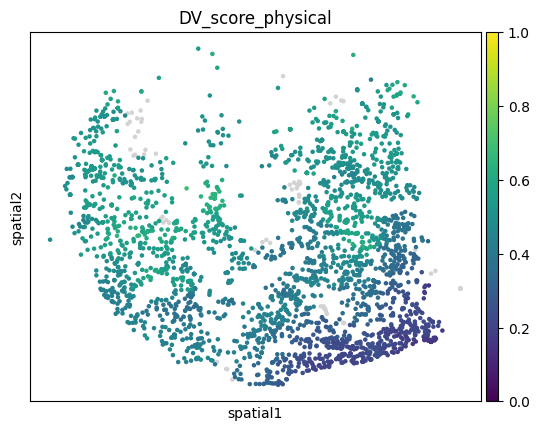

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


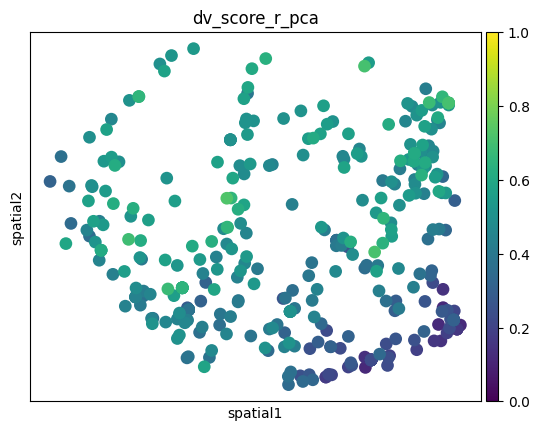

sample_04puck1
Using 31083 / 31198 genes for scoring
This is projection of query dataset
Using provided score_min=-127.6051 and score_max=111.4259 for normalization


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


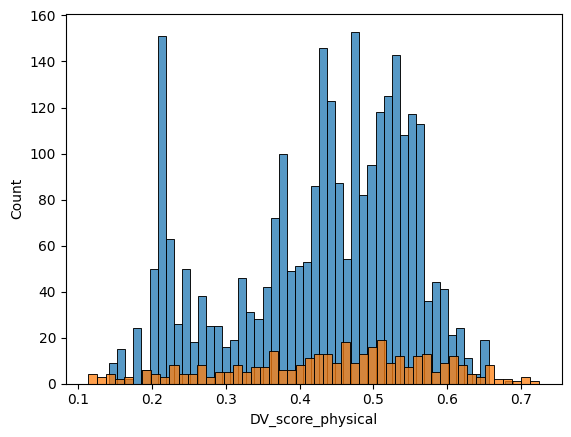

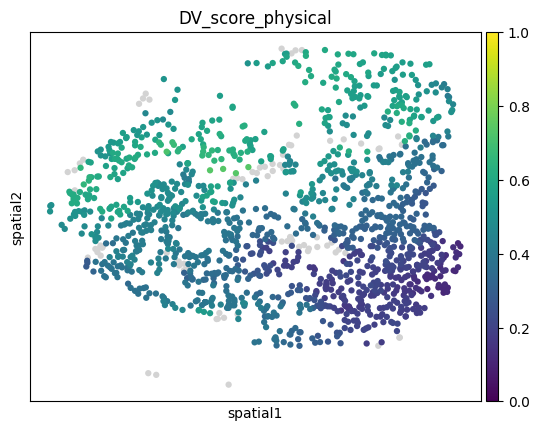

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


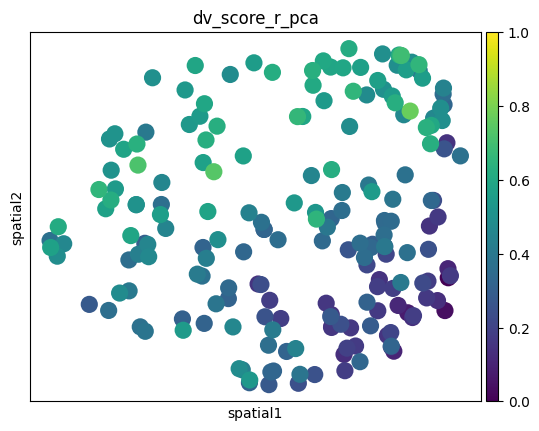

sample_04puck2
Using 31083 / 31198 genes for scoring
This is projection of query dataset
Using provided score_min=-127.6051 and score_max=111.4259 for normalization


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


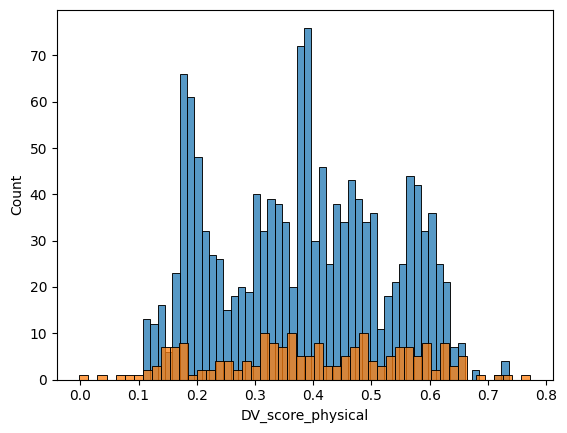

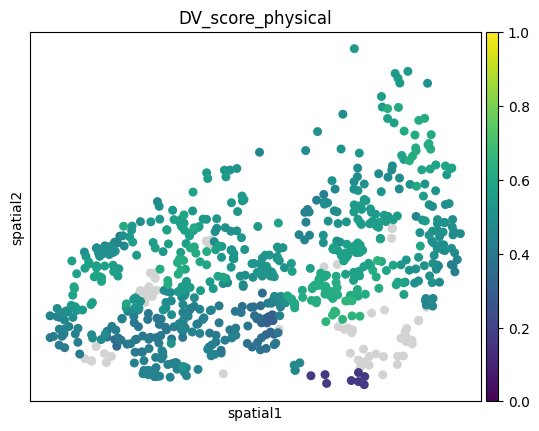

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


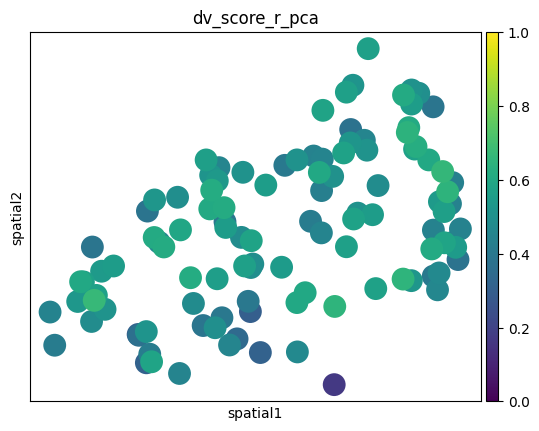

sample_05puck1
Using 31083 / 31198 genes for scoring
This is projection of query dataset
Using provided score_min=-127.6051 and score_max=111.4259 for normalization


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


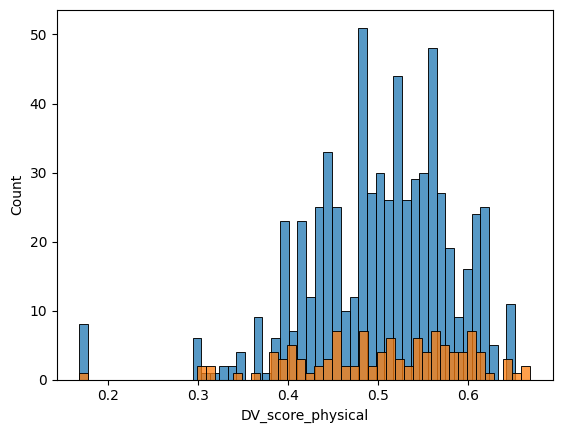

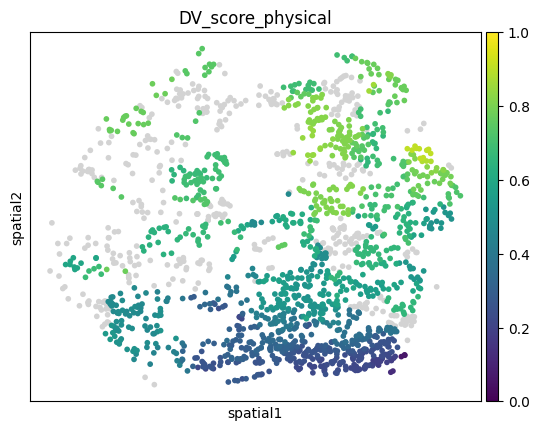

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


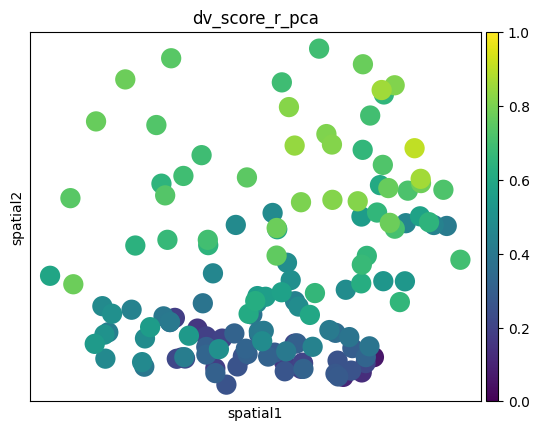

sample_05puck2
Using 31083 / 31198 genes for scoring
This is projection of query dataset
Using provided score_min=-127.6051 and score_max=111.4259 for normalization


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


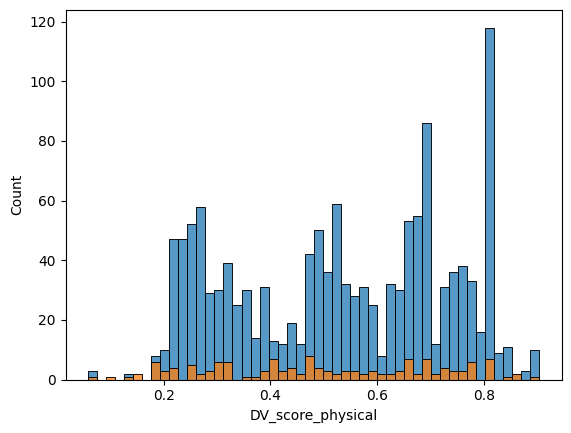

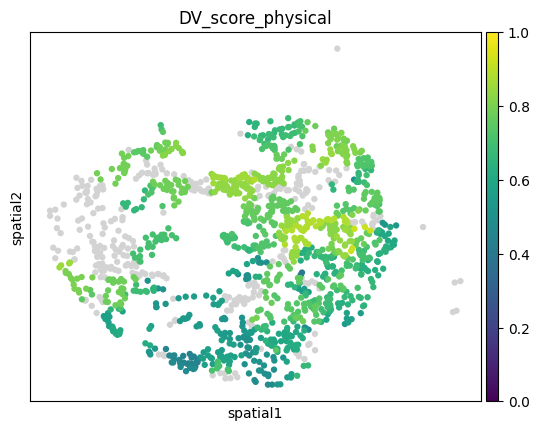

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


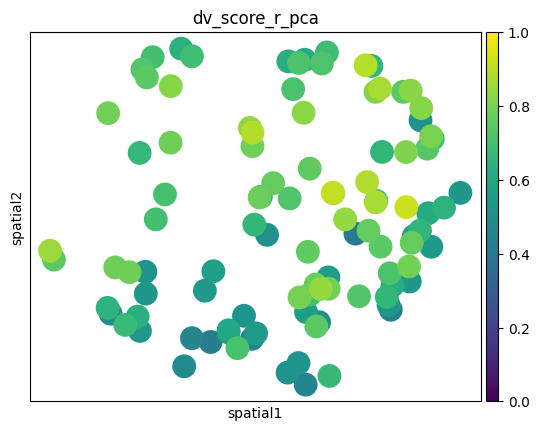

sample_06puck1
Using 31083 / 31198 genes for scoring
This is projection of query dataset
Using provided score_min=-127.6051 and score_max=111.4259 for normalization


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


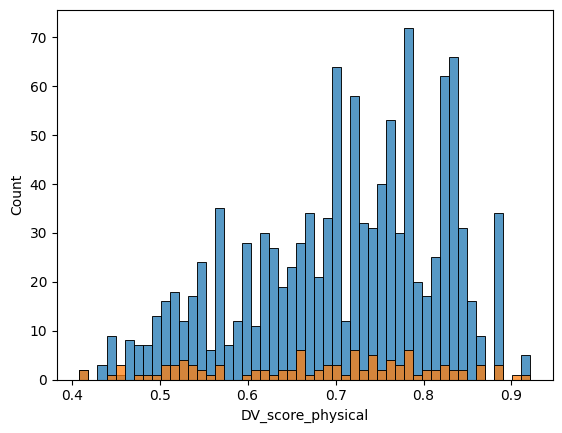

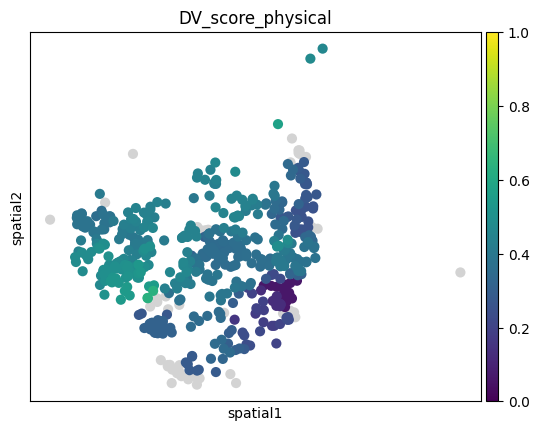

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


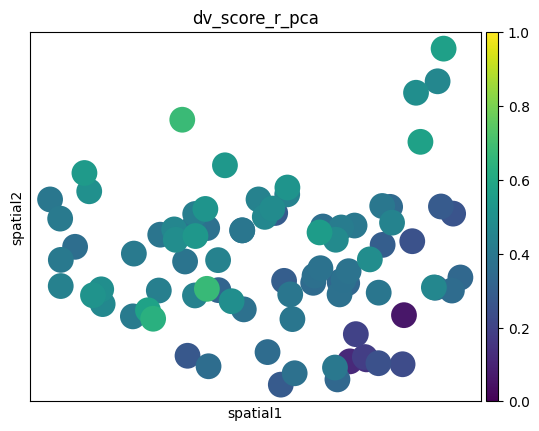

sample_06puck2
Using 31083 / 31198 genes for scoring
This is projection of query dataset
Using provided score_min=-127.6051 and score_max=111.4259 for normalization


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


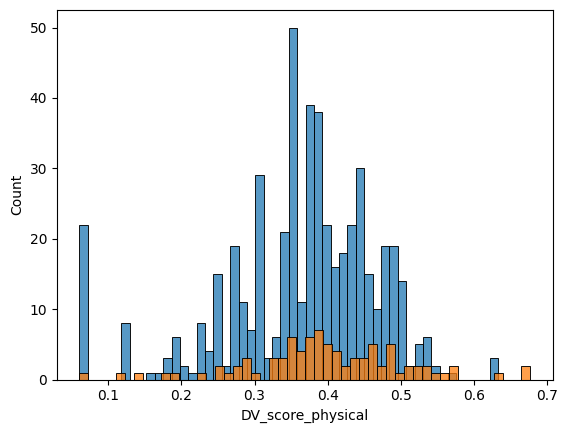

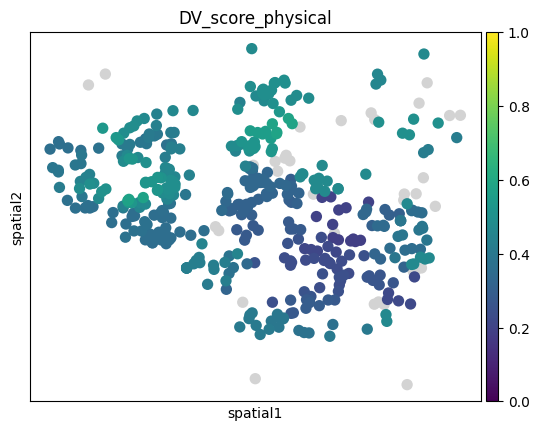

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


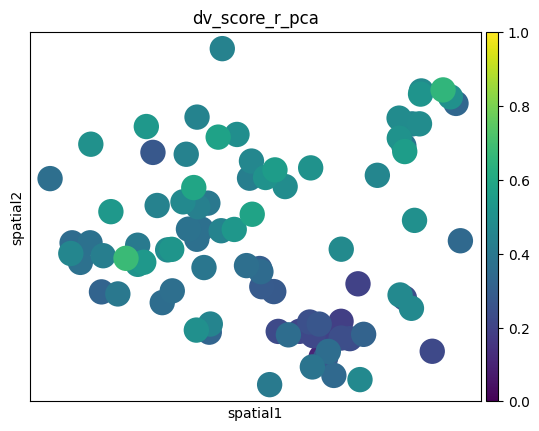

sample_07puck2
Using 31083 / 31198 genes for scoring
This is projection of query dataset
Using provided score_min=-127.6051 and score_max=111.4259 for normalization


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


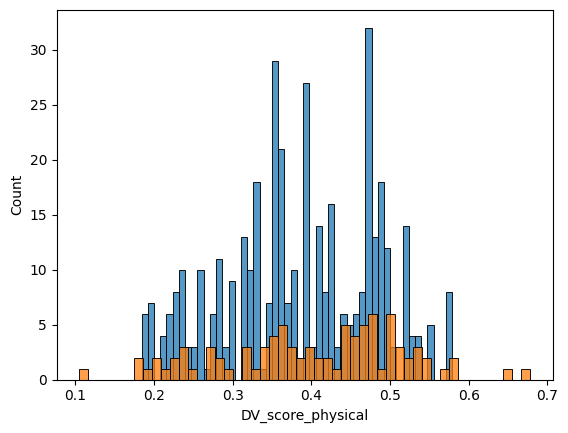

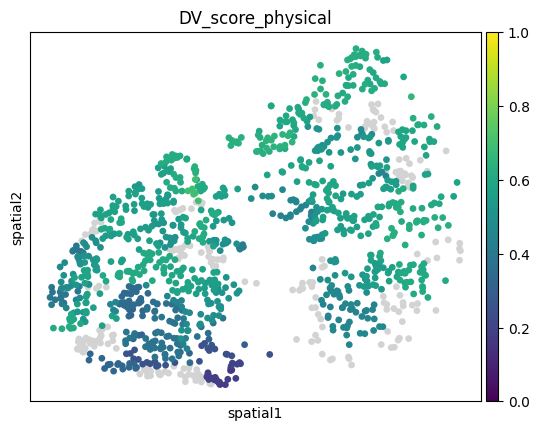

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


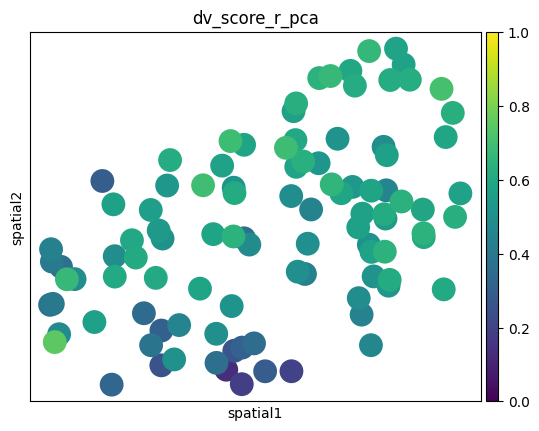

sample_07puck1
Using 31083 / 31198 genes for scoring
This is projection of query dataset
Using provided score_min=-127.6051 and score_max=111.4259 for normalization


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


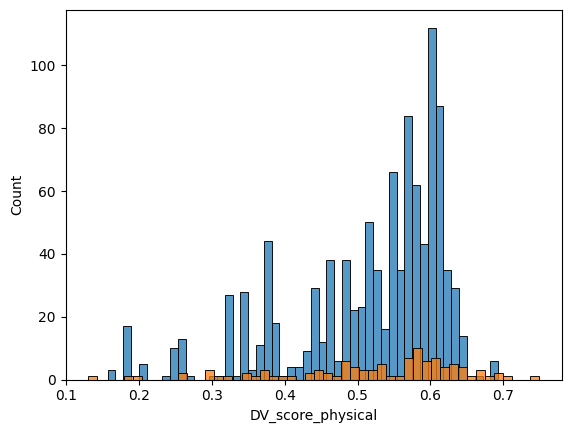

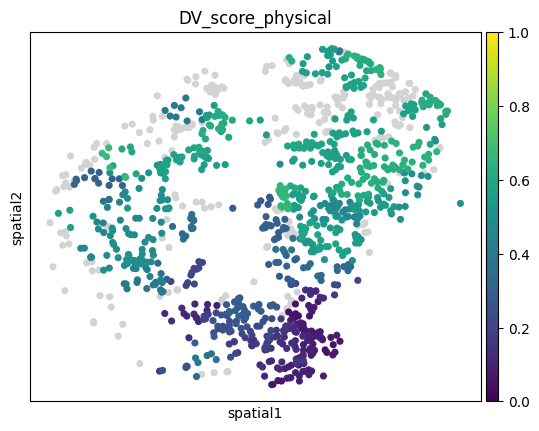

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


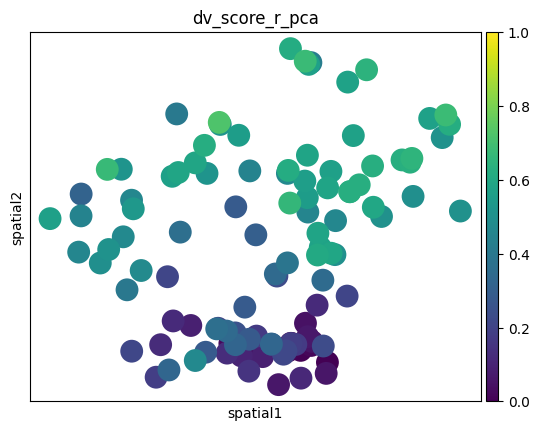

sample_09puck1
Using 31083 / 31198 genes for scoring
This is projection of query dataset
Using provided score_min=-127.6051 and score_max=111.4259 for normalization


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


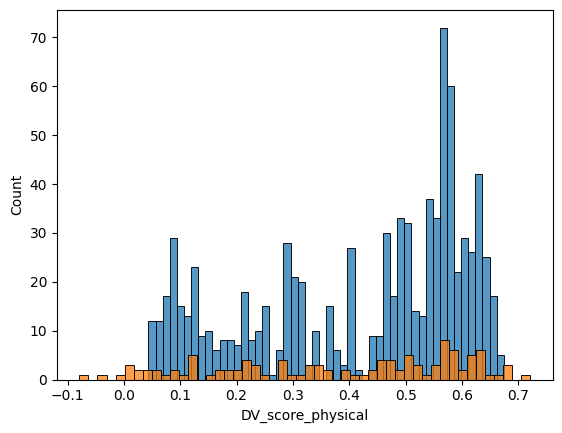

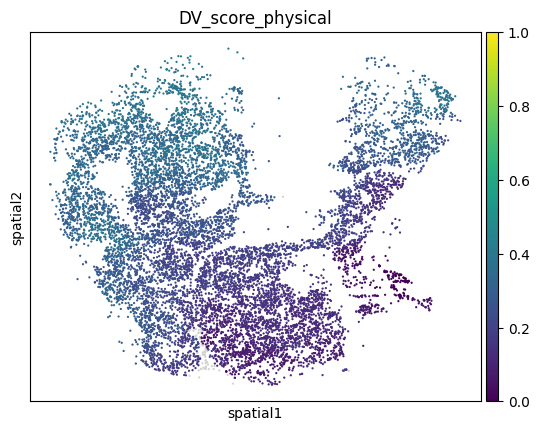

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


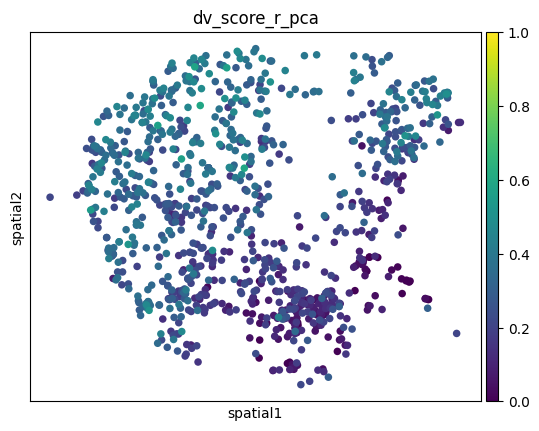

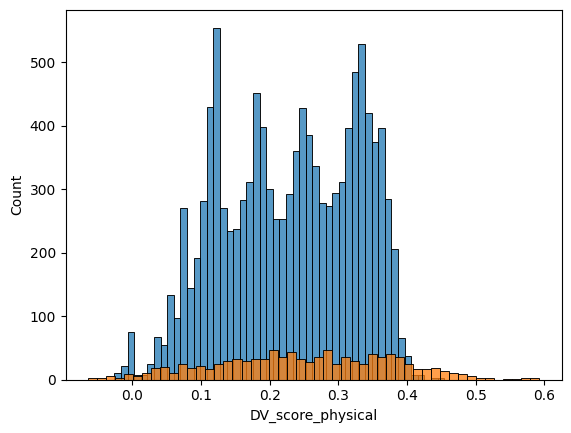

In [28]:
for img in slidetag.obs["image"].unique()[1:]:

    print(img)

    # choose the score
    score ="r_pca"
    dict_score = dict_weights[score]

    # slelct imahe
    slidetag_image = slidetag[
        (slidetag.obs["image"] == img) & 
        (slidetag.obs["ct_for_deg"].isin(["eMSN_D1D2", "Matrix_D1", "Matrix_D2"])) 
        &(slidetag.obs["has_spatial"])
        ].to_memory().copy()
    
    # # Slidetag (after remapping var_names to gene symbols)
    slidetag_image.var_names = slidetag_image.var["gene_symbol"].values.astype(str)
    slidetag_image.var_names_make_unique()

    # claulte socre d1d2
    slidetag_image.obs[dict_score["name_score"]], _, _ = compute_raw_score(slidetag_image, dict_score[f"weights_{score}"], layer="log1p_norm", score_min=dict_score[f"score_min_{score}"], score_max=dict_score[f"score_max_{score}"])

    # caulte socre matirx based on neighbors
    # find d1d2 cells in raodus r from single amtix cell, take mean of s1s2.score as matrix socre
    import numpy as np
    from scipy.spatial import KDTree

    # masks
    d1d2_mask = slidetag_image.obs["ct_for_deg"] == "eMSN_D1D2"
    matrix_mask = slidetag_image.obs["ct_for_deg"].isin(["Matrix_D1", "Matrix_D2"])

    d1d2_coords = slidetag_image[d1d2_mask].obsm["spatial"]       # shape (n_d1d2, 2)
    d1d2_scores = slidetag_image.obs.loc[d1d2_mask, dict_score["name_score"]].values

    matrix_coords = slidetag_image[matrix_mask].obsm["spatial"]   # shape (n_matrix, 2)
    matrix_idx = slidetag_image.obs.index[matrix_mask]

    # Build tree on D1D2 cells, query from Matrix cells
    tree = KDTree(d1d2_coords)
    radius = 1500
    neighbor_indices = tree.query_ball_point(matrix_coords, r=radius)  # list of lists

    # For each Matrix cell: mean D1D2 score of neighbors (NaN if none)
    dv_physical = np.array([
        np.mean(d1d2_scores[idxs]) if len(idxs) > 0 else np.nan
        for idxs in neighbor_indices
    ])

    slidetag_image.obs["DV_score_physical"] = np.nan
    slidetag_image.obs.loc[matrix_idx, "DV_score_physical"] = dv_physical

    sc.pl.embedding(slidetag_image[matrix_mask], basis="spatial", color="DV_score_physical", vmin=0, vmax=1)
    sc.pl.embedding(slidetag_image[d1d2_mask], basis="spatial", color=dict_score["name_score"], vmin=0, vmax=1)
    sns.histplot(slidetag_image.obs[matrix_mask]["DV_score_physical"], bins=50)
    sns.histplot(slidetag_image.obs[d1d2_mask][dict_score["name_score"]], bins=50)

    # repro data on original adata
    slidetag.obs.loc[slidetag_image.obs.index, dict_score["name_score"]] = slidetag_image.obs[dict_score["name_score"]].values
    slidetag.obs.loc[slidetag_image.obs.index, "DV_score_physical"] = slidetag_image.obs["DV_score_physical"].values

    #break







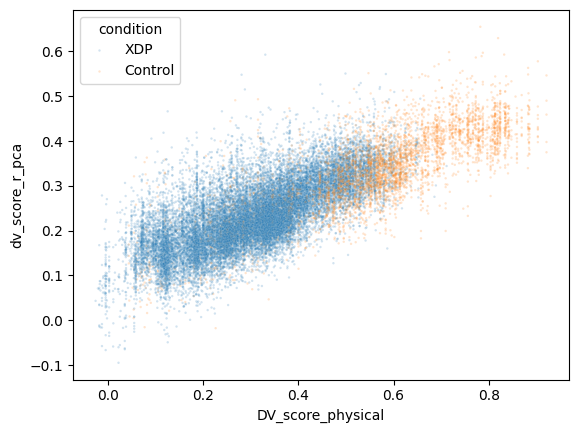

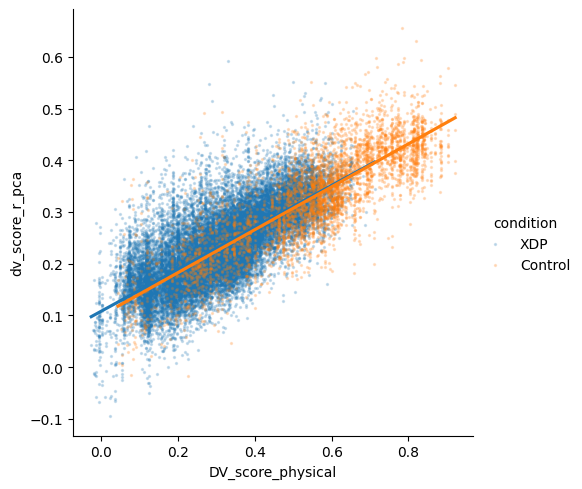

In [44]:
matrix_obs = slidetag.obs[slidetag.obs["ct_for_deg"].isin(["Matrix_D1", "Matrix_D2"])].copy()

#matrix_obs = matrix_obs[matrix_obs["DV_score_physical"] <= 0.5].copy()

sns.scatterplot(matrix_obs, x="DV_score_physical", y="dv_score_r_pca", hue="condition", alpha=0.2, s=3); plt.show()
sns.lmplot(matrix_obs, x="DV_score_physical", y="dv_score_r_pca", hue="condition", scatter_kws={"alpha":0.2, "s":2}); plt.show()

# Veryf how phuscal and trnasptmcla scor ehcges across H and D